### 1. Muat Data

Kita akan memulai dengan memuat dataset Anda ke dalam Pandas DataFrame. Pastikan Anda mengganti `'path/to/your/dataset.csv'` dengan jalur sebenarnya ke file CSV Anda.

In [2]:
import pandas as pd

# Ganti 'path/to/your/dataset.csv' dengan jalur ke file dataset Anda
try:
    df = pd.read_csv('hantavirus_country_yearly.csv')
    print("Dataset berhasil dimuat.")
except FileNotFoundError:
    print("ERROR: File dataset tidak ditemukan. Harap periksa kembali jalurnya.")
    df = None # Set df ke None untuk menghindari error jika file tidak ditemukan

Dataset berhasil dimuat.


### 2. Eksplorasi Data Awal

Setelah data dimuat, mari kita lakukan eksplorasi awal untuk memahami strukturnya, tipe data, dan nilai-nilai yang hilang.

In [3]:
if df is not None:
    print("\n--- 5 Baris Pertama Data ---")
    display(df.head())

    print("\n--- Informasi Data ---")
    df.info()

    print("\n--- Statistik Deskriptif ---")
    display(df.describe(include='all'))
else:
    print("Tidak dapat menampilkan eksplorasi data karena dataset tidak dimuat.")


--- 5 Baris Pertama Data ---


,year,iso3,country,who_region,latitude,longitude,syndrome,confirmed_cases,deaths,recovered,case_fatality_rate,hospitalized,icu_admissions,human_to_human_cases,mortality_rate_per_100k
0,1995,ARG,Argentina,AMRO,-34.6,-58.4,HPS,90,34,56,0.3778,80,34,1,37.36
1,1996,ARG,Argentina,AMRO,-34.6,-58.4,HPS,75,16,59,0.2133,69,29,4,21.05
2,1997,ARG,Argentina,AMRO,-34.6,-58.4,HPS,60,23,37,0.3833,54,16,0,37.70
3,1998,ARG,Argentina,AMRO,-34.6,-58.4,HPS,62,16,46,0.2581,53,20,1,25.40
4,1999,ARG,Argentina,AMRO,-34.6,-58.4,HPS,81,19,62,0.2346,65,23,2,23.17



--- Informasi Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939 entries, 0 to 938
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     939 non-null    int64  
 1   iso3                     939 non-null    object 
 2   country                  939 non-null    object 
 3   who_region               939 non-null    object 
 4   latitude                 939 non-null    float64
 5   longitude                939 non-null    float64
 6   syndrome                 939 non-null    object 
 7   confirmed_cases          939 non-null    int64  
 8   deaths                   939 non-null    int64  
 9   recovered                939 non-null    int64  
 10  case_fatality_rate       939 non-null    float64
 11  hospitalized             939 non-null    int64  
 12  icu_admissions           939 non-null    int64  
 13  human_to_human_cases     939 non-null    int64  
 14  mo

,year,iso3,country,who_region,latitude,longitude,syndrome,confirmed_cases,deaths,recovered,case_fatality_rate,hospitalized,icu_admissions,human_to_human_cases,mortality_rate_per_100k
count,939.000000,939,939,939,939.000000,939.000000,939,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000
unique,NaN,25,25,3,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,CHN,China,EURO,NaN,NaN,HFRS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,76,76,439,NaN,NaN,666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2003.478168,NaN,NaN,NaN,30.898509,19.362087,NaN,1792.774228,58.401491,1734.372737,0.091800,1527.309904,614.744409,0.155485,8.616688
std,16.196564,NaN,NaN,NaN,30.235849,70.510334,NaN,4470.365322,143.630870,4330.633709,0.134477,3832.307507,1558.760229,0.812548,12.655789
min,1950.000000,NaN,NaN,NaN,-34.900000,-79.500000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1995.000000,NaN,NaN,NaN,35.700000,-56.200000,NaN,12.000000,0.000000,11.000000,0.000000,10.000000,3.000000,0.000000,0.000000
50%,2006.000000,NaN,NaN,NaN,39.900000,16.000000,NaN,58.000000,1.000000,50.000000,0.017900,49.000000,19.000000,0.000000,1.750000
75%,2016.000000,NaN,NaN,NaN,50.800000,37.600000,NaN,427.000000,19.000000,410.000000,0.174250,357.000000,138.500000,0.000000,15.480000


### 3. Persiapan Data untuk Model Regresi

Untuk membangun model regresi, kita perlu memilih fitur (variabel independen) dan variabel target (`case_fatality_rate`). Kita juga akan menangani variabel kategorikal dan membagi dataset menjadi set pelatihan dan pengujian.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

if df is not None:
    # Define target variable
    target = 'case_fatality_rate'
    y = df[target]

    # Define features (excluding target, and potentially 'iso3', 'country', 'latitude', 'longitude' for now)
    # 'iso3' and 'country' are highly correlated, using 'country' as it's more readable.
    # 'latitude' and 'longitude' might be too specific or require more complex geographical feature engineering.
    # For simplicity, we'll start with 'year', 'who_region', 'syndrome', 'confirmed_cases', 'deaths',
    # 'recovered', 'hospitalized', 'icu_admissions', 'human_to_human_cases', 'mortality_rate_per_100k'.
    # 'mortality_rate_per_100k' might be highly correlated with 'deaths' and 'case_fatality_rate', we might need to check this later.
    features = [
        'year',
        'who_region',
        'syndrome',
        'confirmed_cases',
        'deaths',
        'recovered',
        'hospitalized',
        'icu_admissions',
        'human_to_human_cases',
        'mortality_rate_per_100k'
    ]
    X = df[features]

    # Identify categorical and numerical features
    categorical_features = ['who_region', 'syndrome']
    numerical_features = [
        'year',
        'confirmed_cases',
        'deaths',
        'recovered',
        'hospitalized',
        'icu_admissions',
        'human_to_human_cases',
        'mortality_rate_per_100k'
    ]

    # Create a column transformer for one-hot encoding categorical features
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Data berhasil dibagi menjadi set pelatihan dan pengujian.")
    print(f"Ukuran X_train: {X_train.shape}")
    print(f"Ukuran X_test: {X_test.shape}")
    print(f"Ukuran y_train: {y_train.shape}")
    print(f"Ukuran y_test: {y_test.shape}")
else:
    print("Tidak dapat melakukan persiapan data karena dataset tidak dimuat.")

Data berhasil dibagi menjadi set pelatihan dan pengujian.
Ukuran X_train: (751, 10)
Ukuran X_test: (188, 10)
Ukuran y_train: (751,)
Ukuran y_test: (188,)


### 4. Membangun dan Melatih Model Regresi

Kita akan menggunakan model Regresi Linear sebagai titik awal. Model ini akan dimasukkan ke dalam pipeline bersama dengan `preprocessor` untuk menangani fitur numerik dan kategorikal secara otomatis.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

if df is not None:
    # Create a pipeline that first preprocesses the data then trains a Linear Regression model
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

    # Train the model
    model.fit(X_train, y_train)

    print("Model Regresi Linear berhasil dilatih.")

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n--- Evaluasi Model ---")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"R-squared (R2): {r2:.4f}")

    # Optionally, display some predictions vs actual values
    predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print("\n--- Contoh Prediksi vs Nilai Aktual ---")
    display(predictions_df.head())
else:
    print("Tidak dapat melatih model karena dataset tidak dimuat atau disiapkan.")

Model Regresi Linear berhasil dilatih.

--- Evaluasi Model ---
Mean Squared Error (MSE): 0.0001
R-squared (R2): 0.9934

--- Contoh Prediksi vs Nilai Aktual ---


,Actual,Predicted
299,0.0314,0.031719
63,0.3659,0.377248
136,0.2500,0.243702
597,0.0034,0.003528
261,0.3333,0.271297


### 5. Visualisasi Prediksi vs. Aktual

Untuk mendapatkan pemahaman visual tentang kinerja model, mari kita plot nilai `case_fatality_rate` aktual terhadap nilai yang diprediksi oleh model.

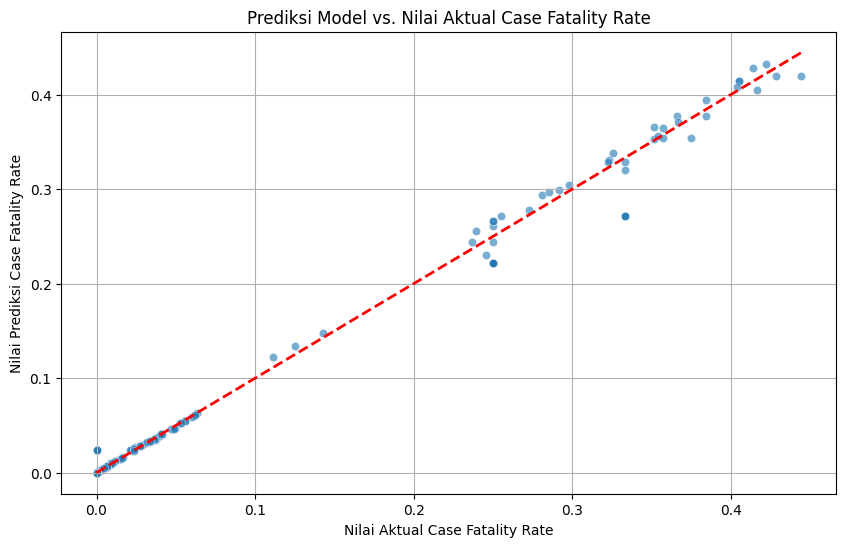

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Garis y=x
    plt.xlabel('Nilai Aktual Case Fatality Rate')
    plt.ylabel('Nilai Prediksi Case Fatality Rate')
    plt.title('Prediksi Model vs. Nilai Aktual Case Fatality Rate')
    plt.grid(True)
    plt.show()
else:
    print("Tidak dapat membuat visualisasi karena dataset tidak dimuat atau model tidak dilatih.")

### 6. Menyimpan Model untuk Pengujian dan Produksi

Model yang sudah dilatih dapat disimpan untuk digunakan kembali di kemudian hari, baik untuk pengujian lebih lanjut atau untuk deployment produksi. Kita akan menggunakan library `joblib`.

In [7]:
import joblib

if model is not None:
    model_filename = 'linear_regression_cfr_model.joblib'
    joblib.dump(model, model_filename)
    print(f"Model berhasil disimpan sebagai '{model_filename}'")
else:
    print("Tidak dapat menyimpan model karena model belum dilatih.")

Model berhasil disimpan sebagai 'linear_regression_cfr_model.joblib'


### 7. Pengujian Model dengan Pytest

Untuk pengujian yang lebih terstruktur dan otomatis, kita bisa menggunakan `pytest`. Kita akan membuat file Python (`test_model.py`) yang berisi fungsi pengujian. Agar `pytest` dapat mengakses data pengujian, kita juga akan menyimpan `X_test` dan `y_test` ke dalam file CSV.

In [8]:
# Simpan X_test dan y_test ke CSV agar bisa diakses oleh pytest
if 'X_test' in locals() and 'y_test' in locals():
    X_test.to_csv('X_test_for_pytest.csv', index=False)
    y_test.to_csv('y_test_for_pytest.csv', index=False)
    print("X_test dan y_test berhasil disimpan untuk pytest.")
else:
    print("X_test atau y_test tidak ditemukan, tidak dapat menyimpan untuk pytest.")

X_test dan y_test berhasil disimpan untuk pytest.


In [9]:
%%writefile test_model.py

import joblib
import pandas as pd
from sklearn.metrics import r2_score

# Lokasi file model dan data uji
MODEL_FILE = 'linear_regression_cfr_model.joblib'
X_TEST_FILE = 'X_test_for_pytest.csv'
Y_TEST_FILE = 'y_test_for_pytest.csv'

def test_model_loading():
    """Uji apakah model dapat dimuat dengan benar."""
    model = joblib.load(MODEL_FILE)
    assert model is not None

def test_model_performance():
    """Uji kinerja model pada data uji yang disimpan."""
    model = joblib.load(MODEL_FILE)
    X_test_loaded = pd.read_csv(X_TEST_FILE)
    y_test_loaded = pd.read_csv(Y_TEST_FILE)

    y_pred = model.predict(X_test_loaded)

    # Assert R-squared is still high (e.g., > 0.95, adjust as needed)
    r2 = r2_score(y_test_loaded, y_pred)
    print(f"\nPytest R2 Score: {r2:.4f}")
    assert r2 > 0.95, f"R2 score {r2:.4f} is not above expected threshold (0.95)"

def test_prediction_output_shape():
    """Uji apakah bentuk output prediksi sudah benar."""
    model = joblib.load(MODEL_FILE)
    X_test_loaded = pd.read_csv(X_TEST_FILE)

    # Ambil satu sampel dari X_test untuk prediksi
    sample_X = X_test_loaded.head(1)
    y_pred_single = model.predict(sample_X)
    assert y_pred_single.shape == (1,)

    # Uji prediksi batch
    y_pred_batch = model.predict(X_test_loaded)
    assert y_pred_batch.shape == (len(X_test_loaded),)

Writing test_model.py


In [10]:
# Install pytest dan jalankan pengujian
!pip install pytest
!pytest test_model.py

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0
rootdir: /content
plugins: anyio-4.13.0, langsmith-0.7.34, typeguard-4.5.1
collected 3 items                                                              

test_model.py ...                                                        [100%]

============================== 3 passed in 1.92s ===============================


### 8. Pengujian Latensi Model

Selanjutnya, kita akan mengukur waktu yang dibutuhkan model untuk melakukan prediksi. Ini penting untuk memahami seberapa cepat model akan merespons dalam lingkungan produksi.

In [11]:
import time
import joblib
import pandas as pd

if 'X_test' in locals():
    # Muat kembali model
    model = joblib.load('linear_regression_cfr_model.joblib')

    # Persiapkan data sampel untuk pengujian latensi
    # Untuk prediksi tunggal
    sample_input = X_test.iloc[[0]] # Ambil satu baris pertama dari X_test

    # Untuk prediksi batch
    batch_input = X_test # Gunakan seluruh X_test sebagai batch

    # === Uji Latensi Prediksi Tunggal ===
    num_runs = 100 # Jumlah pengulangan untuk mendapatkan rata-rata
    total_time_single = 0
    for _ in range(num_runs):
        start_time = time.time()
        _ = model.predict(sample_input)
        end_time = time.time()
        total_time_single += (end_time - start_time)

    avg_latency_single = (total_time_single / num_runs) * 1000 # dalam milidetik
    print(f"\nLatensi rata-rata untuk prediksi tunggal ({num_runs} runs): {avg_latency_single:.4f} ms")

    # === Uji Latensi Prediksi Batch ===
    num_runs_batch = 10 # Jumlah pengulangan untuk batch (kurangi jika dataset besar)
    total_time_batch = 0
    for _ in range(num_runs_batch):
        start_time = time.time()
        _ = model.predict(batch_input)
        end_time = time.time()
        total_time_batch += (end_time - start_time)

    avg_latency_batch = (total_time_batch / num_runs_batch) * 1000 # dalam milidetik
    print(f"Latensi rata-rata untuk prediksi batch ({len(batch_input)} sampel, {num_runs_batch} runs): {avg_latency_batch:.4f} ms")
else:
    print("X_test tidak ditemukan, tidak dapat mengukur latensi.")


Latensi rata-rata untuk prediksi tunggal (100 runs): 4.6063 ms
Latensi rata-rata untuk prediksi batch (188 sampel, 10 runs): 5.2936 ms
